In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import os
import graphviz
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, ExtraTreeClassifier, ExtraTreeRegressor, export_graphviz
from sklearn.metrics import mean_squared_error, r2_score, classification_report, roc_auc_score, confusion_matrix
%matplotlib inline

##### Dataset links  
Regression: https://archive.ics.uci.edu/dataset/165/concrete+compressive+strength  
Classification: https://www.kaggle.com/competitions/titanic/data  

In [2]:
os.makedirs("images", exist_ok=True)
titanic_decision_dot_path = "images/titanic_decision_tree.dot"
concrete_decision_dot_path = "images/concrete_decision_tree.dot"
titanic_extra_tree_dot_path = "images/titanic_extra_tree.dot"
concrete_extra_tree_dot_path = "images/concrete_extra_tree.dot"

### Decision Tree  
Single model that recursively splits features based on an impurity criterion (like Gini or entropy).  
Can capture non-linear patterns.  
Easy to visualize — great for teaching and understanding.  
May overfit  
### Extra Tree
Like Random Forest, but adds randomness in split points, not just in data

### Decision Tree vs. Extra Trees  
| Feature                       | **Decision Tree**                                                  | **Extra Trees** (Extremely Randomized Trees)   |
| ----------------------------- | ------------------------------------------------------------------ | ---------------------------------------------- |
| **Splitting Strategy**        | Chooses the best split based on a metric (e.g. Gini, entropy, MSE) | Chooses **split points randomly** for features |
| **Feature Selection at Node** | Considers **all features** (or a subset in ensemble)               | Same — all or subset                           |
| **Threshold for Splits**      | Finds the **optimal threshold** for each feature                   | Picks a **random threshold** for each feature  |
| **Randomness**                | Only from bootstrapping or sample subset                           | Additional randomness from split thresholds    |
| **Bias / Variance Trade-off** | Lower bias, higher variance                                        | Slightly **higher bias**, **lower variance**   |
| **Speed (training)**          | Slower (due to best split search)                                  | **Faster** (less computation per node)         |
| **Interpretability**          | Easier to explain                                                  | Less interpretable due to randomness           |


### When to Use  
| Use Case                      | Preferred                                                                                   |
| ----------------------------- | ------------------------------------------------------------------------------------------- |
| When accuracy is paramount    | Try both — tune hyperparameters                                                             |
| When speed is important       | **Extra Trees** is usually faster                                                           |
| When interpretability matters | **Decision Tree** (easier to visualize)                                                     |
| For ensembles (like forests)  | Both can be good, but **ExtraTreesClassifier/Regressor** adds regularization via randomness |


# Classification 
Uses Gini impurity or Entropy as criterion  

In [3]:
df_train = pd.read_csv("datasets/titanic/train.csv")
df_test = pd.read_csv("datasets/titanic/test.csv")
print(df_train.shape, df_test.shape)

(891, 12) (418, 11)


In [4]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.0+ KB


In [7]:
y = df_train["Survived"]
df_train.drop(columns = ["Survived"], inplace=True)
y.value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [8]:
# Drop columns that won't help the model
df_train.drop(columns = ["Name", "Cabin", "Ticket"], inplace=True)
df_test.drop(columns = ["Name", "Cabin", "Ticket"], inplace=True)
df_train.shape, df_test.shape

((891, 8), (418, 8))

In [9]:
numerical_cols = ["Pclass", "Age", "SibSp",	"Parch", "Fare"]
categorical_cols = ["Sex", "Embarked"]

In [10]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehotencoder", OneHotEncoder(drop="first", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, numerical_cols),
    ("cat", cat_pipeline, categorical_cols)
])

In [11]:
df_train = preprocessor.fit_transform(df_train)
df_test = preprocessor.fit_transform(df_test)
df_train.shape, df_test.shape

((891, 8), (418, 8))

In [12]:
# Extract the fitted OneHotEncoder from the pipeline
ohe = preprocessor.named_transformers_["cat"].named_steps["onehotencoder"]
# Get one-hot encoded feature names for categorical columns
ohe_feature_names = ohe.get_feature_names_out(categorical_cols)
# Combine numerical and categorical feature names
feature_names = list(numerical_cols) + list(ohe_feature_names)
feature_names

['Pclass',
 'Age',
 'SibSp',
 'Parch',
 'Fare',
 'Sex_male',
 'Embarked_Q',
 'Embarked_S']

### DecisionTreeClassifier

In [13]:
dec_clf = DecisionTreeClassifier(max_depth=5, random_state=42)

In [14]:
dec_scores = cross_val_score(dec_clf, df_train, y, cv=5, scoring="accuracy")
print(dec_scores)

[0.81005587 0.82022472 0.81460674 0.76404494 0.85393258]


In [15]:
dec_clf.fit(df_train, y)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [16]:
export_graphviz(dec_clf, out_file=titanic_decision_dot_path, feature_names=feature_names,
    class_names=["Died", "Survived"],
    filled=True,
    rounded=True)

In [17]:
!dot -Tpng images/titanic_decision_tree.dot -o images/titanic_tree.png

In [18]:
# we can train the model for each alpha and calculate average cross validation score based on accuracy and finally choose the alpha with the best accuracy
# to get the optimal model performance
path = dec_clf.cost_complexity_pruning_path(df_train, y)
path # gives us ccp_alpha(effective alpha) and impurities (MSE for regression, gini impurity or entropy for classification)

{'ccp_alphas': array([0.00000000e+00, 1.26971171e-04, 5.00483592e-04, 9.97630627e-04,
        1.12233446e-03, 1.16950407e-03, 1.40928285e-03, 1.84177962e-03,
        1.92400192e-03, 2.24106188e-03, 2.97853156e-03, 3.33762758e-03,
        3.36449628e-03, 9.97630627e-03, 1.12809002e-02, 1.24396425e-02,
        1.28301312e-02, 3.49754571e-02, 1.39647957e-01]),
 'impurities': array([0.22116919, 0.22129616, 0.22179665, 0.22379191, 0.22491424,
        0.22842275, 0.22983204, 0.23167382, 0.23359782, 0.23583888,
        0.24179594, 0.24513357, 0.25186256, 0.26183887, 0.27311977,
        0.28555941, 0.29838954, 0.333365  , 0.47301296])}

In [19]:
y_train_predict = dec_clf.predict(df_train)
y_test_predict = dec_clf.predict(df_test)

In [20]:
print(classification_report(y, y_train_predict))

              precision    recall  f1-score   support

           0       0.85      0.91      0.88       549
           1       0.83      0.74      0.78       342

    accuracy                           0.84       891
   macro avg       0.84      0.82      0.83       891
weighted avg       0.84      0.84      0.84       891



In [21]:
roc_auc_score(y, y_train_predict)

np.float64(0.821972965199885)

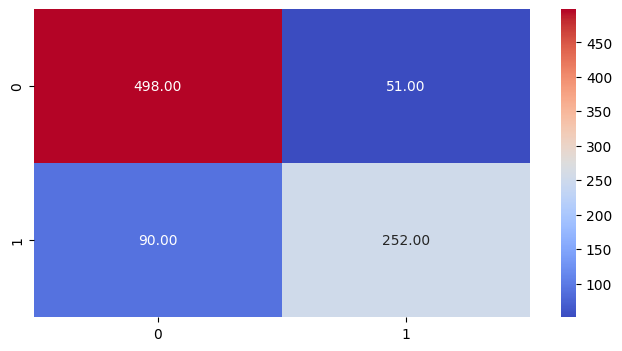

In [22]:
cm = confusion_matrix(y, y_train_predict)
plt.figure(figsize=(8,4))
sns.heatmap(cm, cmap="coolwarm", annot=True, fmt=".2f")
plt.show()

### ExtraTreeClassifier

In [23]:
extra_clf = ExtraTreeClassifier(criterion="entropy", random_state=42, splitter="random")

In [24]:
extra_tree_scores = cross_val_score(extra_clf, df_train, y, cv=5, scoring="accuracy")
print(extra_tree_scores)

[0.77653631 0.76966292 0.80898876 0.75842697 0.79213483]


In [25]:
extra_clf.fit(df_train, y)

ExtraTreeClassifier(criterion='entropy', random_state=42)

In [26]:
export_graphviz(dec_clf, out_file=titanic_extra_tree_dot_path, feature_names=feature_names,
    class_names=["Died", "Survived"],
    filled=True,
    rounded=True)

In [27]:
!dot -Tpng images/titanic_extra_tree.dot -o images/titanic_extra_tree.png

In [28]:
# we can train the model for each alpha and calculate average cross validation score based on accuracy and finally choose the alpha with the best accuracy
# to get the optimal model performance
extra_clf.cost_complexity_pruning_path(df_train, y) # gives us ccp_alpha(effective alpha) and impurities (MSE for regression, gini impurity or entropy for classification)

{'ccp_alphas': array([0.        , 0.00020293, 0.00027113, 0.00047966, 0.00049482,
        0.0005502 , 0.00058204, 0.00069872, 0.00069872, 0.00079293,
        0.00084724, 0.00084724, 0.00084724, 0.0009062 , 0.00091391,
        0.00092491, 0.00093526, 0.00095932, 0.00096998, 0.00105857,
        0.00106629, 0.00107832, 0.00109924, 0.00112085, 0.00121403,
        0.00121403, 0.00121403, 0.00121403, 0.00121612, 0.00122422,
        0.00123414, 0.00123676, 0.00125136, 0.00126702, 0.00127085,
        0.00127085, 0.00133231, 0.00135041, 0.00135041, 0.00136606,
        0.00140445, 0.00144132, 0.00144599, 0.00145909, 0.00145909,
        0.00145909, 0.00148364, 0.00149645, 0.00149645, 0.00150263,
        0.00150337, 0.00154559, 0.00154595, 0.00154595, 0.00154595,
        0.00155648, 0.0015611 , 0.00156223, 0.00159219, 0.00160268,
        0.00167714, 0.00172616, 0.00173238, 0.00179489, 0.00181622,
        0.00182105, 0.00182105, 0.00184453, 0.00185514, 0.00195259,
        0.00195549, 0.00197212, 0.

In [29]:
y_train_extra_tree_predict = extra_clf.predict(df_train)
y_test_extra_tree_predict = extra_clf.predict(df_test)

In [30]:
print(classification_report(y, y_train_extra_tree_predict))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       549
           1       0.99      0.95      0.97       342

    accuracy                           0.98       891
   macro avg       0.98      0.97      0.98       891
weighted avg       0.98      0.98      0.98       891



In [31]:
roc_auc_score(y, y_train_extra_tree_predict)

np.float64(0.9747866935097307)

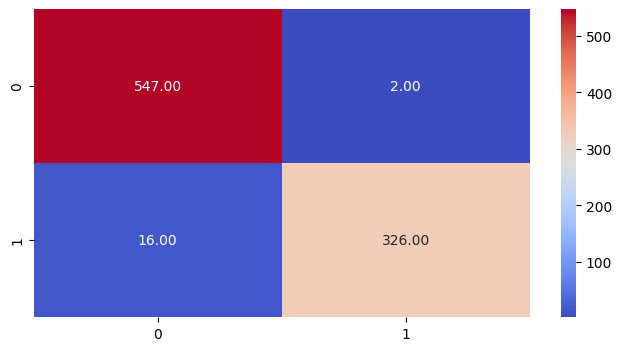

In [32]:
cm = confusion_matrix(y, y_train_extra_tree_predict)
plt.figure(figsize=(8,4))
sns.heatmap(cm, cmap="coolwarm", annot=True, fmt=".2f")
plt.show()

# Regression

In [33]:
df = pd.read_excel("datasets/concrete+compressive+strength/Concrete_Data.xls")
df.shape

(1030, 9)

In [34]:
df.head()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


In [35]:
df.describe()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.165631,73.895485,54.187136,181.566359,6.203112,972.918592,773.578883,45.662136,35.817836
std,104.507142,86.279104,63.996469,21.355567,5.973492,77.753818,80.175427,63.169912,16.705679
min,102.000000,0.000000,0.000000,121.750000,0.000000,801.000000,594.000000,1.000000,2.331808
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.707115
50%,272.900000,22.000000,0.000000,185.000000,6.350000,968.000000,779.510000,28.000000,34.442774
75%,350.000000,142.950000,118.270000,192.000000,10.160000,1029.400000,824.000000,56.000000,46.136287
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.599225


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Cement (component 1)(kg in a m^3 mixture)              1030 non-null   float64
 1   Blast Furnace Slag (component 2)(kg in a m^3 mixture)  1030 non-null   float64
 2   Fly Ash (component 3)(kg in a m^3 mixture)             1030 non-null   float64
 3   Water  (component 4)(kg in a m^3 mixture)              1030 non-null   float64
 4   Superplasticizer (component 5)(kg in a m^3 mixture)    1030 non-null   float64
 5   Coarse Aggregate  (component 6)(kg in a m^3 mixture)   1030 non-null   float64
 6   Fine Aggregate (component 7)(kg in a m^3 mixture)      1030 non-null   float64
 7   Age (day)                                              1030 non-null   int64  
 8   Concrete compressive strength(MPa, megapascals)  

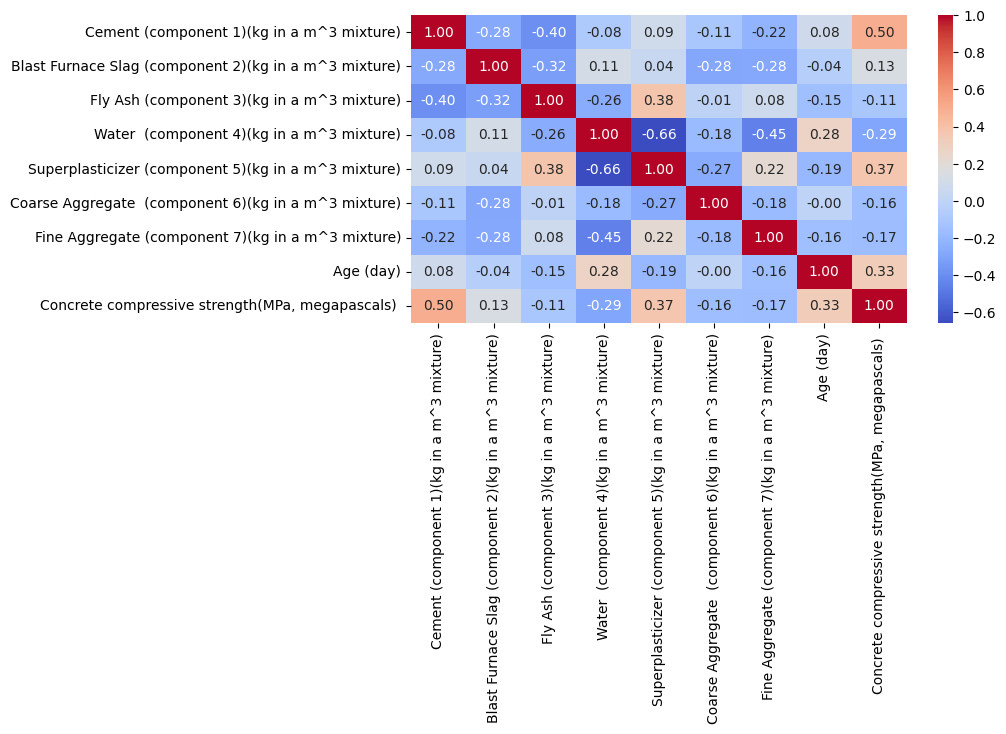

In [37]:
plt.figure(figsize=(8,4))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

In [38]:
y = df["Concrete compressive strength(MPa, megapascals) "]
df.drop(columns=["Concrete compressive strength(MPa, megapascals) "], inplace=True)
X = df.copy()

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((824, 8), (824,), (206, 8), (206,))

In [40]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### DecisionTreeRegressor

In [41]:
dec_reg = DecisionTreeRegressor(random_state=42, max_depth=3)
dec_reg.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=3, random_state=42)

In [42]:
export_graphviz(dec_clf, out_file=concrete_decision_dot_path, feature_names=feature_names,
    filled=True,
    rounded=True)

In [43]:
!dot -Tpng images/concrete_decision_tree.dot -o images/concrete_decision_tree.png

In [44]:
# we can train the model for each alpha and calculate average cross validation score based on accuracy and finally choose the alpha with the best accuracy
# to get the optimal model performance
dec_reg.cost_complexity_pruning_path(X_train, y_train) # gives us ccp_alpha(effective alpha) and impurities (MSE for regression, gini impurity or entropy for classification)

{'ccp_alphas': array([ 0.        ,  2.65648452,  4.61106794, 16.34215944, 16.37301762,
        20.27074903, 50.47064245, 72.84622079]),
 'impurities': array([100.5123901 , 103.16887462, 107.77994257, 124.12210201,
        140.49511963, 160.76586866, 211.23651111, 284.0827319 ])}

In [45]:
y_train_pred = dec_reg.predict(X_train)
y_test_pred = dec_reg.predict(X_test)

In [46]:
print(f"Train Accuracy: {mean_squared_error(y_train, y_train_pred)}")
print(f"Train R2-score: {r2_score(y_train, y_train_pred)}")
print(f"Test Accuracy: {mean_squared_error(y_test, y_test_pred)}")
print(f"Test R2-score: {r2_score(y_test, y_test_pred)}")

Train Accuracy: 100.51239009870058
Train R2-score: 0.6461862027792452
Test Accuracy: 135.81066685675893
Test R2-score: 0.4729505845329307


### ExtraTreeRegressor

In [47]:
extra_reg = ExtraTreeRegressor(random_state=42, splitter="random", max_depth=5)
extra_reg.fit(X_train, y_train)

ExtraTreeRegressor(max_depth=5, random_state=42)

In [48]:
export_graphviz(dec_clf, out_file=concrete_extra_tree_dot_path, feature_names=feature_names,
    filled=True,
    rounded=True)

In [49]:
!dot -Tpng images/concrete_extra_tree.dot -o images/concrete_extra_tree.png

In [50]:
extra_reg.cost_complexity_pruning_path(X_train, y_train)

{'ccp_alphas': array([ 0.        ,  0.09820936,  0.13284492,  0.17117316,  0.27749344,
         0.45512258,  0.5411706 ,  0.54452114,  0.85465265,  1.053118  ,
         1.42789337,  1.55320314,  2.01391539,  2.14915389,  2.86878104,
         2.98623769,  3.07519831,  4.01529877,  4.74555697,  4.80790141,
         9.08218348, 13.33818869, 20.95990914, 45.21481469]),
 'impurities': array([ 92.25270201,  92.35091137,  92.4837563 ,  92.65492946,
         92.9324229 ,  93.38754548,  93.92871608,  95.01775835,
         95.872411  ,  96.92552901,  98.35342237, 101.45982865,
        103.47374404, 105.62289793, 114.22924105, 117.21547875,
        123.36587537, 127.38117415, 132.12673112, 136.93463253,
        146.016816  , 172.69319338, 193.65310251, 284.0827319 ])}

In [51]:
y_train_extra_tree_pred = extra_reg.predict(X_train)
y_test_extra_tree_pred = extra_reg.predict(X_test)

In [52]:
print(f"Train Accuracy: {mean_squared_error(y_train, y_train_extra_tree_pred)}")
print(f"Train R2-score: {r2_score(y_train, y_train_extra_tree_pred)}")
print(f"Test Accuracy: {mean_squared_error(y_test, y_test_extra_tree_pred)}")
print(f"Test R2-score: {r2_score(y_test, y_test_extra_tree_pred)}")

Train Accuracy: 92.25270200752263
Train R2-score: 0.6752611417447698
Test Accuracy: 104.41326323837167
Test R2-score: 0.5947965603111661
